# 06 - How we fit the LSM distribution: methods side by side (stage-share view)

Notebook 04 picked one method: a lognormal calibrated to the fibrosis stage
shares, weighting F1/F2/F3 above F4. This notebook puts the candidate methods
side by side against the empirical data, on the pooled 2017-2023 sample, and makes
three things obvious:

1. The project's priority is the **stage-share vector** (F0-F4), because the
   simulation routes simulants by the 6/8/10/15 kPa ladder. F1/F2/F3 matter more
   than F4.
2. **Single-anchor F4 calibration** (the old method) and **log-moment match** (a
   colleague's table) pin the tail or the bulk but miss F1/F2/F3 by several
   percentage points. **Multi-cutoff calibration** pins F1/F2/F3 by construction.
3. The cost is real and structural: a two-parameter lognormal -- the downstream
   contract -- cannot also carry the empirical >=15 kPa tail. Only a categorical
   stage vector reproduces every stage exactly, and that needs a downstream change.


In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import lsm_cap_fit as L
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

pool = pd.read_parquet(L.POOLED_PARQUET)
ana = L.assign_band(L.analysis_frame(pool, 'LSM'))
older = ana[ana['age_years'] >= 60]
BANDS = L.band_edges(start=60, top=80)
F4_KPA = L.LSM_CUTOFFS[-1]           # 15 kPa == F4 boundary on the new ladder
print(f'pooled LSM adults 60+: n = {len(older):,}')
print(older.groupby('cycle').size().to_string())


pooled LSM adults 60+: n = 5,005
cycle
2017_2020    2653
2021_2023    2352


## 1. Empirical stage shares per cell

For each (sex, band): the weighted F0-F4 shares (the routing fractions), plus the
median (anchors the F4-calibrated fit) and log-moments (the colleague's method).


In [2]:
rows = []
for sex in ['Female', 'Male']:
    for lo, hi, lab in BANDS:
        sub = older[(older['sex'] == sex) & (older['age_start'] == lo)]
        if len(sub) < 30:
            continue
        y, w = sub['LSM_KPA'].values.astype(float), sub['MEC_WT_POOL'].values.astype(float)
        sh = L.empirical_stage_shares(y, w, L.LSM_CUTOFFS)
        rows.append(dict(sex=sex, age_start=lo, age_group=lab, n=len(sub),
                         median=L.w_quantile(y, w, .5),
                         mean=L.w_mean(y, w), sd=L.w_sd(y, w),
                         log_mean=L.w_log_mean(y, w), log_sd=L.w_log_sd(y, w),
                         f4=sh[4], **{st: sh[i] for i, st in enumerate(L.LSM_STAGES)}))
emp = pd.DataFrame(rows)
print(emp[['sex', 'age_group', 'n'] + L.LSM_STAGES]
      .assign(**{s: (emp[s] * 100).round(1) for s in L.LSM_STAGES}).to_string(index=False))


   sex age_group   n   F0   F1  F2  F3  F4
Female     60-64 778 72.7 16.4 4.3 4.5 2.0
Female     65-69 659 70.9 16.5 5.2 5.2 2.2
Female     70-74 485 69.6 17.5 5.8 3.9 3.2
Female     75-79 319 72.9 18.8 4.0 2.2 2.1
Female       80+ 328 70.7 19.8 4.5 2.1 2.9
  Male     60-64 760 63.1 21.5 6.3 5.3 3.7
  Male     65-69 557 59.8 24.7 4.9 7.2 3.4
  Male     70-74 493 57.4 23.6 6.7 7.0 5.3
  Male     75-79 287 61.7 24.6 3.8 6.6 3.3
  Male       80+ 339 62.2 20.2 8.4 5.9 3.3


## 2. Cross-check: the colleague's table is the pooled log-moment match

A team member committed `nhanes_rf_distributions.csv` in the consuming repo; its
`LSM` / `LSM_sd` columns are the weighted mean / SD of `log(LSM)`. They should
match our pooled `log_mean` / `log_sd`, confirming the only difference from the
old P_LUX-alone table is pooling. (Skipped gracefully if the sibling repo is absent.)


In [3]:
COLLEAGUE = (L.ROOT.parent / 'vivarium_csu_mace_rct' / 'src'
             / 'vivarium_csu_mace_rct' / 'data' / 'nhanes_rf_distributions.csv')
try:
    coll = pd.read_csv(COLLEAGUE).rename(columns={'Sex': 'sex'})[['age5', 'sex', 'LSM', 'LSM_sd']]
    chk = emp.merge(coll, left_on=['sex', 'age_start'], right_on=['sex', 'age5'], how='inner')
    if len(chk):
        rms_m = float(np.sqrt(np.mean((chk['log_mean'] - chk['LSM']) ** 2)))
        rms_s = float(np.sqrt(np.mean((chk['log_sd'] - chk['LSM_sd']) ** 2)))
        print(f'overlap cells: {len(chk)} | RMS residual log_mean={rms_m:.3f}, log_sd={rms_s:.3f}')
        print(chk[['sex', 'age_group', 'n', 'log_mean', 'LSM', 'log_sd', 'LSM_sd']].round(3).to_string(index=False))
    else:
        print('no overlapping (sex, age) cells with the colleague table (they start at age 25).')
except FileNotFoundError:
    print(f'colleague table not found at {COLLEAGUE} - skipping cross-check.')


overlap cells: 10 | RMS residual log_mean=0.018, log_sd=0.026
   sex age_group   n  log_mean   LSM  log_sd  LSM_sd
Female     60-64 778     1.626 1.643   0.424   0.434
Female     65-69 659     1.647 1.661   0.421   0.436
Female     70-74 485     1.657 1.672   0.426   0.454
Female     75-79 319     1.634 1.646   0.380   0.403
Female       80+ 328     1.649 1.674   0.358   0.401
  Male     60-64 760     1.759 1.780   0.480   0.512
  Male     65-69 557     1.735 1.758   0.446   0.477
  Male     70-74 493     1.799 1.819   0.552   0.567
  Male     75-79 287     1.753 1.770   0.446   0.471
  Male       80+ 339     1.742 1.758   0.465   0.483


## 3. The candidate fits, judged on stage shares

For each cell we fit three lognormals and read off their implied F0-F4 shares:

| Method | How | Anchors |
| --- | --- | --- |
| **log-moment match** (colleague) | mu, sigma = mean, sd of log(LSM) | the bulk |
| **F4-calibrated** (old project) | mu = log(median); sigma so P[>=15] = empirical F4 | the F4 tail |
| **multi-cutoff calibrated** (notebook 04) | minimise weighted stage-share error, F1/F2/F3 up-weighted | F1/F2/F3 |

All three are lognormals -- the downstream contract -- so this is an apples-to-apples
comparison of what a two-parameter family can be made to pin.


In [4]:
def shares(mu, sg):
    return L.lognorm_stage_shares(mu, sg, L.LSM_CUTOFFS)

fit_rows = []
for _, r in emp.iterrows():
    sub = older[(older['sex'] == r['sex']) & (older['age_start'] == r['age_start'])]
    y, w = sub['LSM_KPA'].values.astype(float), sub['MEC_WT_POOL'].values.astype(float)
    mm = shares(*L.fit_log_mm(y, w))
    mu_f4, sg_f4 = L.fit_lognorm_f4(r['median'], r['f4'], cutoff=F4_KPA)
    f4 = shares(mu_f4, sg_f4) if not np.isnan(sg_f4) else np.full(5, np.nan)
    mc = shares(*L.fit_lognorm_multicut(y, w))
    for i, st in enumerate(L.LSM_STAGES):
        fit_rows.append(dict(sex=r['sex'], age_group=r['age_group'], stage=st,
                             emp=r[st], logMM=mm[i], F4cal=f4[i], multicut=mc[i]))
fit = pd.DataFrame(fit_rows)

# error summary by method
summary = {}
for method in ['logMM', 'F4cal', 'multicut']:
    err = (fit[method] - fit['emp']) * 100
    f123 = fit['stage'].isin(['F1', 'F2', 'F3'])
    f4m = fit['stage'] == 'F4'
    summary[method] = dict(mean_abs_F1F2F3=np.abs(err[f123]).mean(),
                           max_abs_F1F2F3=np.abs(err[f123]).max(),
                           mean_abs_F4=np.abs(err[f4m]).mean())
print('Stage-share error (percentage points) by method:')
print(pd.DataFrame(summary).T.round(2).to_string())


Stage-share error (percentage points) by method:
          mean_abs_F1F2F3  max_abs_F1F2F3  mean_abs_F4
logMM                3.46            8.52         1.69
F4cal                3.92            6.89         0.00
multicut             1.27            4.97         2.70


## 4. Where each method spends its error

Mean absolute stage-share error by stage x method. The F4-calibrated bar is ~0 at
F4 by construction but tall at F1/F2/F3; multi-cutoff is the mirror image. That is
the whole trade, in one picture.


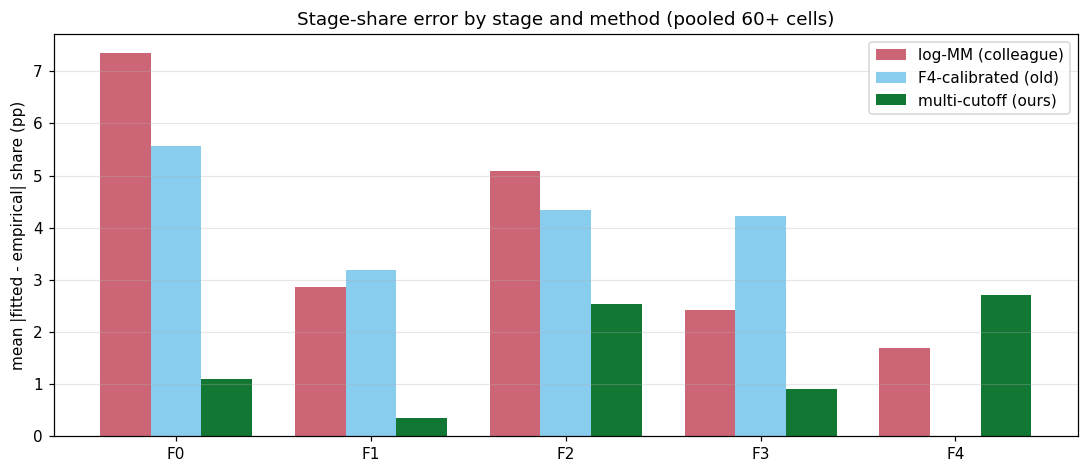

In [5]:
by_stage = (fit.assign(**{m: (fit[m] - fit['emp']).abs() for m in ['logMM', 'F4cal', 'multicut']})
              .groupby('stage')[['logMM', 'F4cal', 'multicut']].mean() * 100).reindex(L.LSM_STAGES)
x = np.arange(len(L.LSM_STAGES)); wbar = 0.26
fig, ax = plt.subplots(figsize=(10, 4.4))
for i, (m, c, lab) in enumerate([('logMM', '#cc6677', 'log-MM (colleague)'),
                                 ('F4cal', '#88ccee', 'F4-calibrated (old)'),
                                 ('multicut', '#117733', 'multi-cutoff (ours)')]):
    ax.bar(x + (i - 1) * wbar, by_stage[m], wbar, color=c, label=lab)
ax.set_xticks(x); ax.set_xticklabels(L.LSM_STAGES)
ax.set_ylabel('mean |fitted - empirical| share (pp)')
ax.set_title('Stage-share error by stage and method (pooled 60+ cells)')
ax.legend(); ax.grid(True, alpha=0.3, axis='y'); fig.tight_layout(); plt.show()


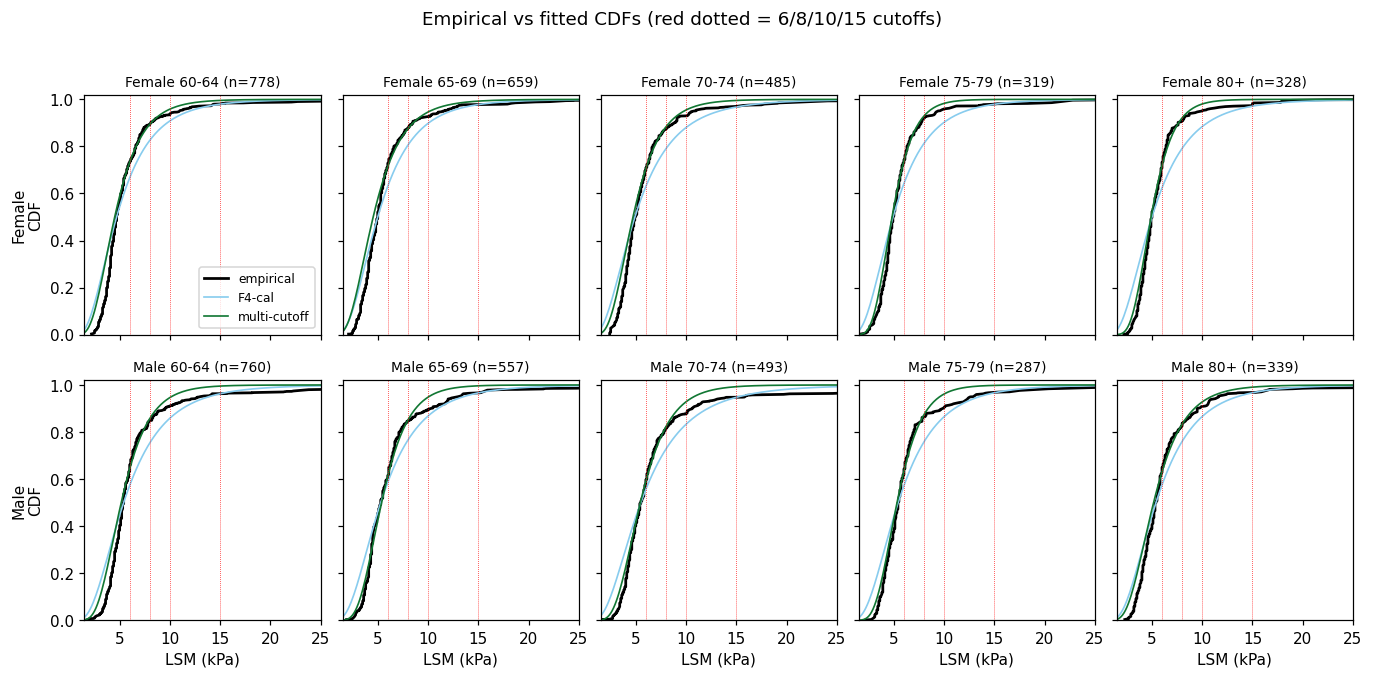

In [6]:
# CDF small multiples: empirical vs F4-calibrated vs multi-cutoff, ladder marked.
fig, axes = plt.subplots(2, len(BANDS), figsize=(2.5 * len(BANDS), 6), sharex=True, sharey=True)
for i, sex in enumerate(['Female', 'Male']):
    for j, (lo, hi, lab) in enumerate(BANDS):
        ax = axes[i, j]
        sub = older[(older['sex'] == sex) & (older['age_start'] == lo)]
        r = emp[(emp['sex'] == sex) & (emp['age_start'] == lo)]
        if len(sub) < 30 or len(r) == 0:
            ax.set_axis_off(); continue
        r = r.iloc[0]
        y, w = sub['LSM_KPA'].values, sub['MEC_WT_POOL'].values
        o = np.argsort(y); ax.plot(y[o], np.cumsum(w[o]) / w.sum(), color='black', lw=1.8, label='empirical')
        grid = np.linspace(1.5, 30, 200)
        mu_f4, sg_f4 = L.fit_lognorm_f4(r['median'], r['f4'], cutoff=F4_KPA)
        if not np.isnan(sg_f4):
            ax.plot(grid, stats.lognorm.cdf(grid, sg_f4, scale=np.exp(mu_f4)),
                    color='#88ccee', lw=1.1, label='F4-cal')
        mu_mc, sg_mc = L.fit_lognorm_multicut(y, w)
        ax.plot(grid, stats.lognorm.cdf(grid, sg_mc, scale=np.exp(mu_mc)),
                color='#117733', lw=1.1, label='multi-cutoff')
        for c in L.LSM_CUTOFFS:
            ax.axvline(c, color='red', ls=':', lw=0.5)
        ax.set_title(f'{sex} {lab} (n={int(r["n"])})', fontsize=9)
        ax.set_xlim(1.5, 25); ax.set_ylim(0, 1.02)
        if j == 0: ax.set_ylabel(f'{sex}\nCDF')
        if i == 1: ax.set_xlabel('LSM (kPa)')
        if i == 0 and j == 0: ax.legend(fontsize=8, loc='lower right')
fig.suptitle('Empirical vs fitted CDFs (red dotted = 6/8/10/15 cutoffs)', y=1.02)
fig.tight_layout(); plt.show()


## 5. What we ship, and the open question

The loader consumes `liver_stiffness_age_sex_lognormal.csv` (notebook 04, extended
over the skeleton in notebook 05): per-(sex, age) `mean_kpa` / `sd_kpa` of the
**multi-cutoff-calibrated** lognormal. That choice pins F1/F2/F3 -- the stages the
project cares about most -- at the cost of the F4 tail.

**The structural limit.** No two-parameter family reproduces the empirical stage
vector exactly: the body implies a sigma too thin to carry the >=15 kPa tail, and
the narrow F2 band (8-10) sits below the wide F3 band (10-15) in several male
cells, a shoulder a unimodal density cannot bend to. The error plot shows every
lognormal method paying somewhere.

**Open questions for the team:**

1. If cirrhosis (F4) routing accuracy is also required, the only exact fix is to
   ship the empirical **stage-share vector** (categorical) instead of `(mean, sd)`,
   which needs the downstream exposure component and the threshold router changed
   to consume a category. Worth it?
2. Ladder alignment: these fits use 6/8/10/15 kPa. The simulation must route on the
   same cutoffs; if it still bins F4 at 12.5, the realised cirrhosis share will
   differ from what we calibrated.
3. CAP is now delivered too (`cap_age_sex_distribution.csv`, moment-matched Normal)
   but is not yet wired downstream.
